## Импорты

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,confusion_matrix, RocCurveDisplay,roc_curve)
from sklearn.inspection import permutation_importance


## Работа с данными

In [43]:
df = pd.read_csv("./student-por.csv",sep=";")

target = (df['G3'] < 10).astype(int)
df = df.drop(columns="G3")

#one hot encoding
df = pd.get_dummies(df,drop_first=True)


## Графики

<Axes: >

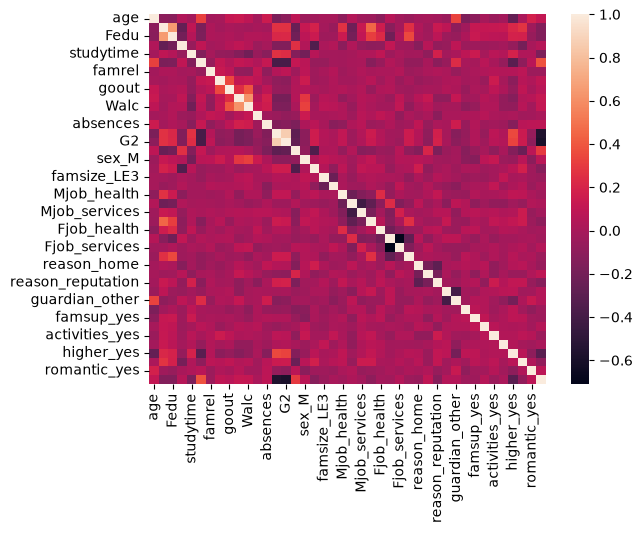

In [45]:
sns.heatmap(df.join(target).corr())

## Работа с моделями

In [18]:
KNN = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=31))
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight='balanced'))
rf = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)

x_train,x_val,y_train,y_val = train_test_split(df,target,test_size=0.15,stratify=target,random_state=42)
rf.fit(x_train,y_train)
logreg.fit(x_train,y_train)


cv = StratifiedKFold(5,shuffle=True,random_state=42)
print("KNN:",cross_val_score(KNN,df,target,cv = cv,scoring="roc_auc").mean())
print("LR:",cross_val_score(logreg,df,target,cv = cv,scoring="roc_auc").mean())
print("RF:",cross_val_score(rf,df,target,cv = cv,scoring="roc_auc").mean())


KNN: 0.9018219349457881
LR: 0.9435863219349457
RF: 0.9697072560467056


## Порог

[[77  6]
 [ 3 12]]

              precision    recall  f1-score   support

       зачёт       0.96      0.93      0.94        83
     незачёт       0.67      0.80      0.73        15

    accuracy                           0.91        98
   macro avg       0.81      0.86      0.84        98
weighted avg       0.92      0.91      0.91        98



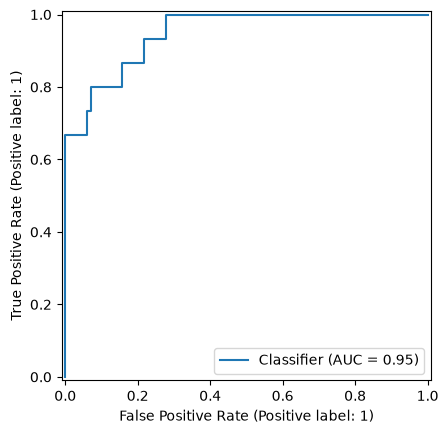

In [16]:
proba = rf.predict_proba(x_val)[:, 1]
threshold = 0.5   # TODO: подберите осмысленный порог и обоснуйте его
Uden_index = []  

#Подбор оптимального порога по индексу Юдена
fpr, tpr, thresholds = roc_curve(y_val, proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

pred = (proba >= optimal_threshold).astype(int)
print(confusion_matrix(y_val, pred))
print()
print(classification_report(y_val, pred, target_names=['зачёт', 'незачёт']))

RocCurveDisplay.from_predictions(y_val, proba)
plt.show()


## Три главных фактора

ТОП-3 фактора:
  1. G2                   падение ROC-AUC при перемешивании: 0.1229
  2. G1                   падение ROC-AUC при перемешивании: 0.0630
  3. guardian_mother      падение ROC-AUC при перемешивании: 0.0043


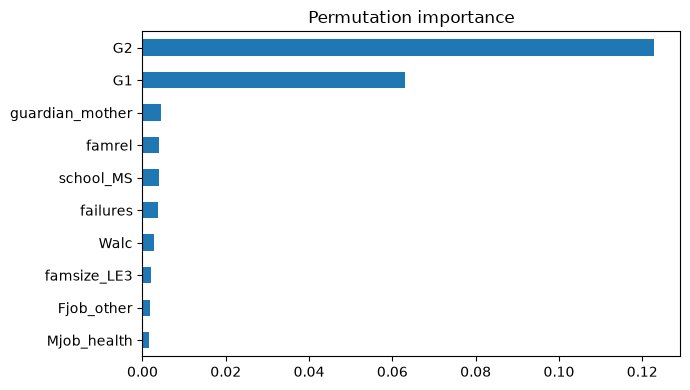

Сильнее всего СНИЖАЮТ риск незачёта:
G2               -3.867
G1               -2.477
age              -0.781
activities_yes   -0.347
Mjob_teacher     -0.270
dtype: float64

Сильнее всего ПОВЫШАЮТ риск незачёта:
Mjob_health        0.287
failures           0.452
Fjob_other         0.522
guardian_mother    0.550
school_MS          0.681
dtype: float64


In [19]:
r = permutation_importance(rf, x_val, y_val, n_repeats=30, random_state=42, scoring='roc_auc')
imp = pd.Series(r.importances_mean, index=df.columns).sort_values(ascending=False)

print('ТОП-3 фактора:')
for i, (name, val) in enumerate(imp.head(3).items(), 1):
    print(f'  {i}. {name:20s} падение ROC-AUC при перемешивании: {val:.4f}')

top = imp.head(10)[::-1]
top.plot(kind='barh', figsize=(7, 4))
plt.title('Permutation importance'); plt.tight_layout(); plt.show()

coefs = pd.Series(logreg.named_steps['logisticregression'].coef_[0], index=df.columns).sort_values()
print('Сильнее всего СНИЖАЮТ риск незачёта:'); print(coefs.head(5).round(3))
print('\nСильнее всего ПОВЫШАЮТ риск незачёта:'); print(coefs.tail(5).round(3))